In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [72]:
df = pd.read_csv('ref_data.csv')
df.head()

,Time (h),Aeration rate(Fg:L/h),Substrate concentration(S:g/L),Dissolved oxygen concentration(DO2:mg/L),Penicillin concentration(P:g/L),pH(pH:pH),Temperature(T:K),Generated heat(Q:kJ),carbon dioxide percent in off-gas(CO2outgas:%),Batch ID
0,0.2,30,0.95749,14.711,1.017800e-25,6.4472,298.22,0.000001,0.089514,1
1,0.4,30,1.00460,14.699,1.000000e-03,6.4932,298.17,0.000001,0.101760,1
2,0.6,30,1.04980,14.686,9.993400e-04,6.5425,298.14,0.000001,0.105800,1
3,0.8,30,1.09420,14.661,9.987400e-04,6.5753,298.11,0.000001,0.108190,1
4,1.0,30,1.13700,14.633,9.982100e-04,6.5825,298.09,0.000001,0.110300,1


## Part 1

In [97]:
col = list(df.columns)[5]

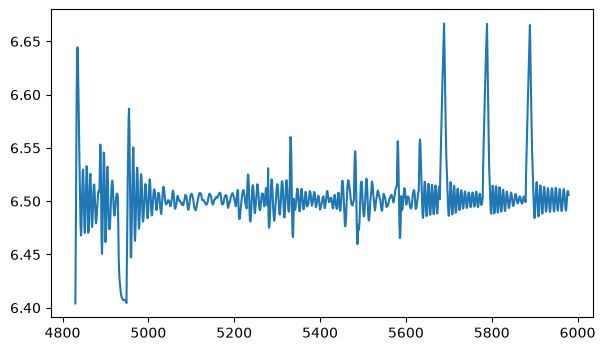

In [98]:
fig,ax = plt.subplots(figsize=(7,4))
ax.plot(df[df['Batch ID'] == 10][col])
plt.show()

In [99]:
df.describe()

,Time (h),Aeration rate(Fg:L/h),Substrate concentration(S:g/L),Dissolved oxygen concentration(DO2:mg/L),Penicillin concentration(P:g/L),pH(pH:pH),Temperature(T:K),Generated heat(Q:kJ),carbon dioxide percent in off-gas(CO2outgas:%),Batch ID
count,78250.000000,78250.000000,78250.000000,78250.000000,7.825000e+04,78250.000000,78250.000000,78250.000000,78250.000000,78250.00000
mean,114.280767,65.333610,2.039840,12.462238,1.505494e+01,6.496138,298.019670,277.430655,1.461009,44.38492
std,66.801343,11.558497,8.149241,1.507462,1.010754e+01,0.063423,0.147064,132.374223,0.466865,24.00709
min,0.200000,30.000000,0.000006,1.000000,1.017800e-25,5.395700,297.350000,0.000001,0.076045,1.00000
25%,56.800000,60.000000,0.001000,11.541000,5.756725e+00,6.493200,297.950000,180.680000,1.300725,23.00000
50%,113.600000,65.000000,0.001520,12.526000,1.589100e+01,6.500800,297.990000,275.970000,1.615400,47.00000
75%,170.200000,75.000000,0.002558,13.463000,2.361800e+01,6.508300,298.040000,363.337500,1.768000,64.00000
max,290.000000,75.000000,86.975000,16.270000,3.618300e+01,6.758900,300.860000,1110.100000,2.233500,88.00000


In [124]:
p01 = df[col].quantile(.01)
p99 = df[col].quantile(.99)
p50 = df[col].quantile(.5)

In [118]:
df1 = pd.read_csv('fault_batch_1.csv')
df1.head()

,Time (h),Aeration rate(Fg:L/h),Substrate concentration(S:g/L),Dissolved oxygen concentration(DO2:mg/L),Penicillin concentration(P:g/L),pH(pH:pH),Temperature(T:K),Generated heat(Q:kJ),carbon dioxide percent in off-gas(CO2outgas:%),Batch ID
0,0.2,30,0.97209,14.626,0.001000,6.4492,297.73,157.31,0.085222,4
1,0.4,30,1.02150,14.600,0.000999,6.4892,297.90,201.35,0.096214,4
2,0.6,30,1.06940,14.581,0.000999,6.5360,297.88,195.40,0.099911,4
3,0.8,30,1.11560,14.550,0.000998,6.5704,298.11,258.44,0.102160,4
4,1.0,30,1.16000,14.525,0.000998,6.5771,298.02,234.03,0.104200,4


In [119]:
sum(df1[col] < p01)

0

In [120]:
sum(df1[col] > p99)

31

In [121]:
l = df1.shape[0]
print(f'TS length: {l}')

TS length: 1150


In [122]:
n_outliers = sum(df1[col] < p01) + sum(df1[col] > p99)
print(n_outliers)

31


In [123]:
p_outliers = n_outliers/l
print(f'Proportion of outliesr: {np.round(p_outliers*100,decimals=2)}%')

Proportion of outliesr: 2.7%


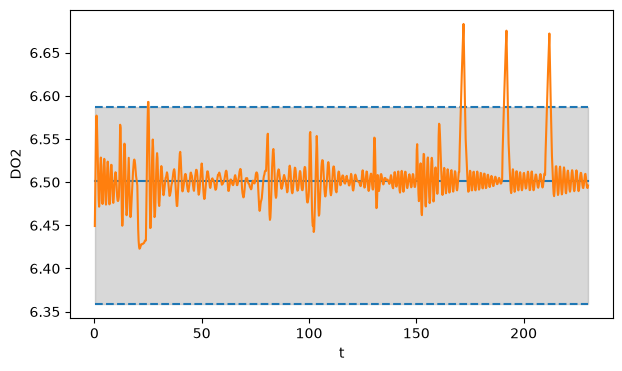

In [125]:
fig,ax = plt.subplots(figsize=(7,4))

t0 = df1['Time (h)'].min()
t1 = df1['Time (h)'].max()
ax.fill([t0,t1,t1,t0],[p01,p01,p99,p99],color='gray',alpha=.3)
ax.plot([t0,t1],[p01,p01],'--',color='C0')
ax.plot([t0,t1],[p99,p99],'--',color='C0')
ax.plot([t0,t1],[p50,p50],color='C0')

ax.plot(df1['Time (h)'],df1[col],color='C1')

ax.set_xlabel('t')
ax.set_ylabel('DO2')

plt.show()

In [126]:
cols = list(df1.columns)

In [127]:
for c in cols:
    q01 = df[c].quantile(.01)
    q99 = df[c].quantile(.99)

    n_outliers = sum(df1[c] < q01) + sum(df1[c] > q99)
    l = df1.shape[0]
    p_outliers = n_outliers/l

    print('For column '+c+f': proportion of outliers {np.round(p_outliers*100,decimals=2)}% ({n_outliers})')
    

For column Time (h): proportion of outliers 0.96% (11)
For column Aeration rate(Fg:L/h): proportion of outliers 0.0% (0)
For column Substrate concentration(S:g/L): proportion of outliers 0.0% (0)
For column Dissolved oxygen concentration(DO2:mg/L): proportion of outliers 8.7% (100)
For column Penicillin concentration(P:g/L): proportion of outliers 1.04% (12)
For column pH(pH:pH): proportion of outliers 2.7% (31)
For column Temperature(T:K): proportion of outliers 0.7% (8)
For column Generated heat(Q:kJ): proportion of outliers 0.0% (0)
For column carbon dioxide percent in off-gas(CO2outgas:%): proportion of outliers 1.04% (12)
For column Batch ID: proportion of outliers 0.0% (0)


## Part 2 

In [132]:
col = 'Temperature(T:K)'
df.head()

,Time (h),Aeration rate(Fg:L/h),Substrate concentration(S:g/L),Dissolved oxygen concentration(DO2:mg/L),Penicillin concentration(P:g/L),pH(pH:pH),Temperature(T:K),Generated heat(Q:kJ),carbon dioxide percent in off-gas(CO2outgas:%),Batch ID
0,0.2,30,0.95749,14.711,1.017800e-25,6.4472,298.22,0.000001,0.089514,1
1,0.4,30,1.00460,14.699,1.000000e-03,6.4932,298.17,0.000001,0.101760,1
2,0.6,30,1.04980,14.686,9.993400e-04,6.5425,298.14,0.000001,0.105800,1
3,0.8,30,1.09420,14.661,9.987400e-04,6.5753,298.11,0.000001,0.108190,1
4,1.0,30,1.13700,14.633,9.982100e-04,6.5825,298.09,0.000001,0.110300,1


In [133]:
q1 = df[col].quantile(.25)
q2 = df[col].quantile(.5)
q3 = df[col].quantile(.75)
iqr = q3 - q1

print(f'Q1 = {q1}, Q3 = {q3}, IQR = {iqr}')

Q1 = 297.95, Q3 = 298.04, IQR = 0.09000000000003183


In [134]:
l_whisker = q1 - 1.5*iqr
u_whisker = q3 + 1.5*iqr

print(f'Lower whisker: {l_whisker}')
print(f'Upper whisker: {u_whisker}')

Lower whisker: 297.81499999999994
Upper whisker: 298.17500000000007


In [135]:
df2 = pd.read_csv('fault_batch_2.csv')
df2.head()

,Time (h),Aeration rate(Fg:L/h),Substrate concentration(S:g/L),Dissolved oxygen concentration(DO2:mg/L),Penicillin concentration(P:g/L),pH(pH:pH),Temperature(T:K),Generated heat(Q:kJ),carbon dioxide percent in off-gas(CO2outgas:%),Batch ID
0,0.2,30,1.1557,14.668,0.001000,6.4766,297.92,28.966,0.084908,5
1,0.4,30,1.2076,14.648,0.000999,6.4813,297.95,37.566,0.095882,5
2,0.6,30,1.2582,14.617,0.000999,6.4968,297.92,29.716,0.099472,5
3,0.8,30,1.3068,14.603,0.000998,6.5129,298.04,61.778,0.101630,5
4,1.0,30,1.3535,14.578,0.000998,6.5234,297.98,44.498,0.103560,5


In [137]:
out_of_whisker = sum(df2[col] < l_whisker) + sum(df2[col] > u_whisker)
print(f'Number of outliers: {out_of_whisker}')

Number of outliers: 525


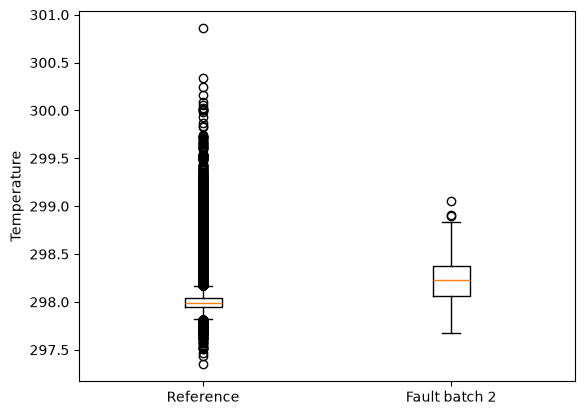

In [140]:
fig,ax = plt.subplots()

ax.boxplot([df[col],df2[col]])

ax.set_xticklabels(['Reference','Fault batch 2'])
ax.set_ylabel('Temperature')

plt.show()

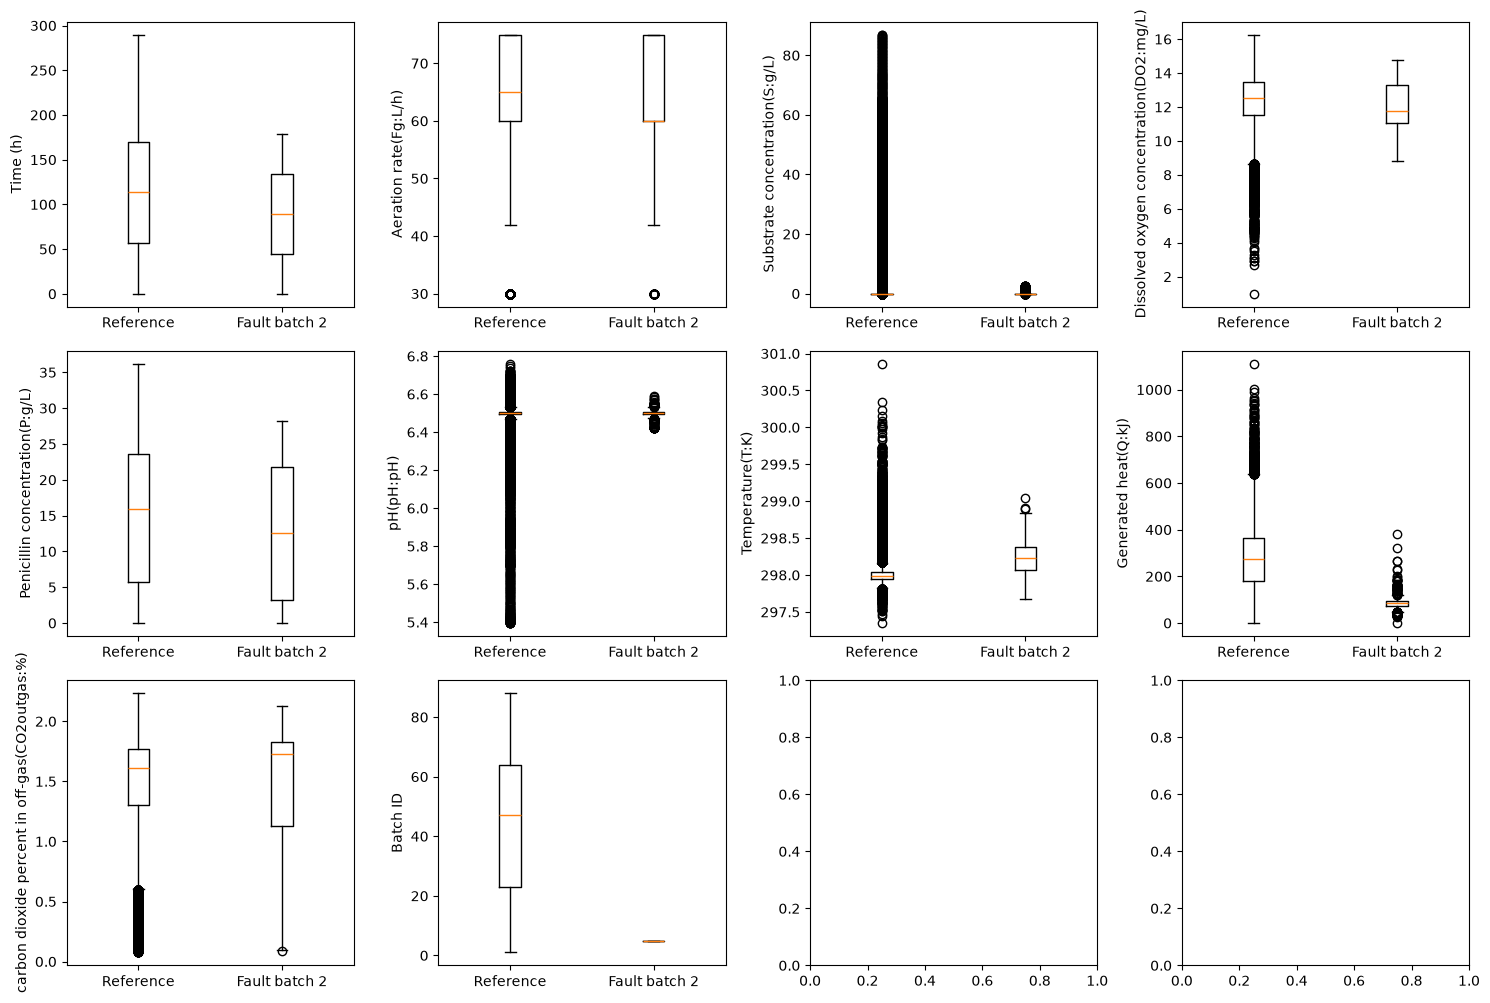

In [148]:
fig,axes = plt.subplots(nrows=3,ncols=4,figsize=(15,10))

for i,ax in enumerate(axes.flat[:10]):
    ax.boxplot([df[cols[i]],df2[cols[i]]])

    ax.set_xticklabels(['Reference','Fault batch 2'])
    ax.set_ylabel(cols[i])

plt.tight_layout()
plt.show()    


# Part 3

In [149]:
df3 = pd.read_csv('fault_batch_3.csv')
df3.head()

,Time (h),Aeration rate(Fg:L/h),Substrate concentration(S:g/L),Dissolved oxygen concentration(DO2:mg/L),Penicillin concentration(P:g/L),pH(pH:pH),Temperature(T:K),Generated heat(Q:kJ),carbon dioxide percent in off-gas(CO2outgas:%),Batch ID
0,0.2,30,1.1299,14.665,0.001000,6.5512,297.44,392.99,0.085819,6
1,0.4,30,1.1801,14.645,0.001000,6.5303,297.82,492.70,0.096824,6
2,0.6,30,1.2289,14.630,0.000999,6.5103,297.80,487.07,0.100500,6
3,0.8,30,1.2761,14.611,0.000999,6.4911,298.28,613.98,0.102750,6
4,1.0,30,1.3221,14.590,0.000998,6.4787,298.11,570.07,0.104780,6


In [153]:
df0 = df[df['Batch ID'] == 10]
df0.head()

,Time (h),Aeration rate(Fg:L/h),Substrate concentration(S:g/L),Dissolved oxygen concentration(DO2:mg/L),Penicillin concentration(P:g/L),pH(pH:pH),Temperature(T:K),Generated heat(Q:kJ),carbon dioxide percent in off-gas(CO2outgas:%),Batch ID
4830,0.2,30,1.0440,14.731,0.001000,6.4041,297.51,322.59,0.085214,10
4831,0.4,30,1.0908,14.708,0.000999,6.4705,297.84,409.58,0.096502,10
4832,0.6,30,1.1366,14.684,0.000998,6.5372,297.82,404.15,0.100350,10
4833,0.8,30,1.1809,14.672,0.000998,6.5988,298.23,515.62,0.102710,10
4834,1.0,30,1.2238,14.650,0.000997,6.6362,298.10,479.66,0.104820,10


In [ ]:
acf3 = [df3['tre200d0'].autocorr(lag=tau) for tau in range(1,4000)]
acf_df = [df['tre200d0'].autocorr(lag=tau) for tau in range(1,4000)]


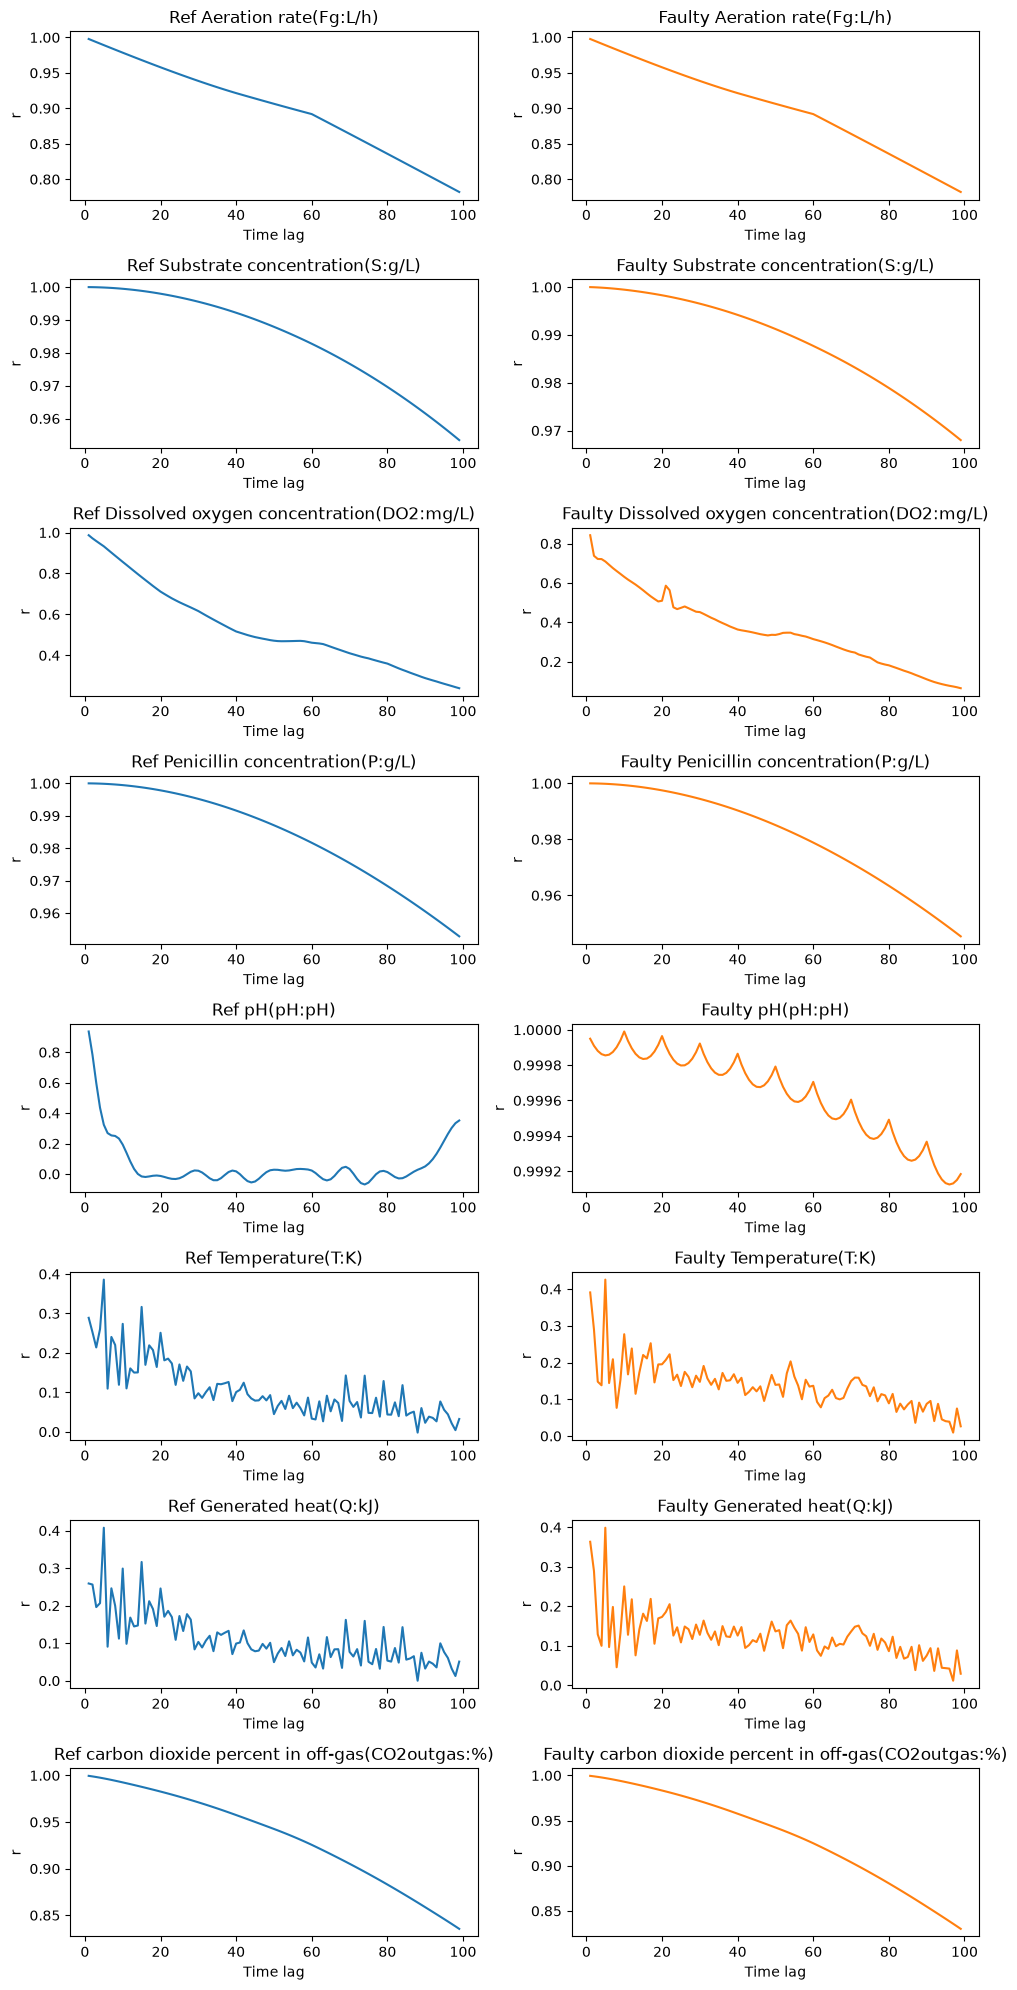

In [157]:
fig,axes = plt.subplots(nrows=8, ncols=2, figsize=(10,20))

for i in range(1,9):
    acf3 = [df3[cols[i]].autocorr(lag=tau) for tau in range(1,100)]
    acf0 = [df0[cols[i]].autocorr(lag=tau) for tau in range(1,100)]

    ax = axes[i-1,0]
    ax.plot(range(1,100),acf0,color='C0')
    ax.set_xlabel('Time lag')
    ax.set_ylabel('r')
    ax.set_title('Ref '+cols[i])

    ax = axes[i-1,1]
    ax.plot(range(1,100),acf3,color='C1')
    ax.set_xlabel('Time lag')
    ax.set_ylabel('r')
    ax.set_title('Faulty '+cols[i])

plt.tight_layout()
plt.show()
